In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('../Datasets/WineScores.csv')
df

,points,Bordeaux-style Red Blend,Cabernet Sauvignon,Chardonnay,Pinot Noir,Red Blend
0,80,5.0,87.0,68.0,36.0,72.0
1,81,18.0,159.0,150.0,83.0,107.0
2,82,72.0,435.0,517.0,295.0,223.0
3,83,95.0,570.0,669.0,346.0,364.0
4,84,268.0,923.0,1146.0,733.0,602.0
5,85,310.0,1048.0,1244.0,873.0,587.0
6,86,354.0,1194.0,1472.0,1218.0,871.0
7,87,510.0,1566.0,1809.0,1726.0,1233.0
8,88,498.0,1141.0,1416.0,1474.0,1260.0
9,89,433.0,908.0,969.0,1154.0,928.0


In [3]:
df = df.rename(columns={'Bordeaux-style Red Blend':'Bordeaux-style_Red_Blend','Cabernet Sauvignon':'Cabernet_Sauvignon','Pinot Noir':'Pinot_Noir','Red Blend':'Red_Blend'})
df

,points,Bordeaux-style_Red_Blend,Cabernet_Sauvignon,Chardonnay,Pinot_Noir,Red_Blend
0,80,5.0,87.0,68.0,36.0,72.0
1,81,18.0,159.0,150.0,83.0,107.0
2,82,72.0,435.0,517.0,295.0,223.0
3,83,95.0,570.0,669.0,346.0,364.0
4,84,268.0,923.0,1146.0,733.0,602.0
5,85,310.0,1048.0,1244.0,873.0,587.0
6,86,354.0,1194.0,1472.0,1218.0,871.0
7,87,510.0,1566.0,1809.0,1726.0,1233.0
8,88,498.0,1141.0,1416.0,1474.0,1260.0
9,89,433.0,908.0,969.0,1154.0,928.0


In [4]:
df.dtypes

points                        int64
Bordeaux-style_Red_Blend    float64
Cabernet_Sauvignon          float64
Chardonnay                  float64
Pinot_Noir                  float64
Red_Blend                   float64
dtype: object

In [7]:
df.isnull().sum()

points                      0
Bordeaux-style_Red_Blend    1
Cabernet_Sauvignon          0
Chardonnay                  1
Pinot_Noir                  0
Red_Blend                   0
dtype: int64

In [11]:
df[df["Bordeaux-style_Red_Blend"].isnull()]

,points,Bordeaux-style_Red_Blend,Cabernet_Sauvignon,Chardonnay,Pinot_Noir,Red_Blend
20,100,NaN,3.0,3.0,2.0,2.0


In [10]:
df["Bordeaux-style_Red_Blend"][df["Bordeaux-style_Red_Blend"].isnull()]

20   NaN
Name: Bordeaux-style_Red_Blend, dtype: float64

In [12]:
df = df.fillna(0)

In [13]:
df.isnull().sum()

points                      0
Bordeaux-style_Red_Blend    0
Cabernet_Sauvignon          0
Chardonnay                  0
Pinot_Noir                  0
Red_Blend                   0
dtype: int64

Which wine has highest total count?

In [14]:
df.drop("points", axis=1).sum().sort_values(ascending=False)

Chardonnay                  13775.0
Pinot_Noir                  13628.0
Cabernet_Sauvignon          12671.0
Red_Blend                    9378.0
Bordeaux-style_Red_Blend     4545.0
dtype: float64

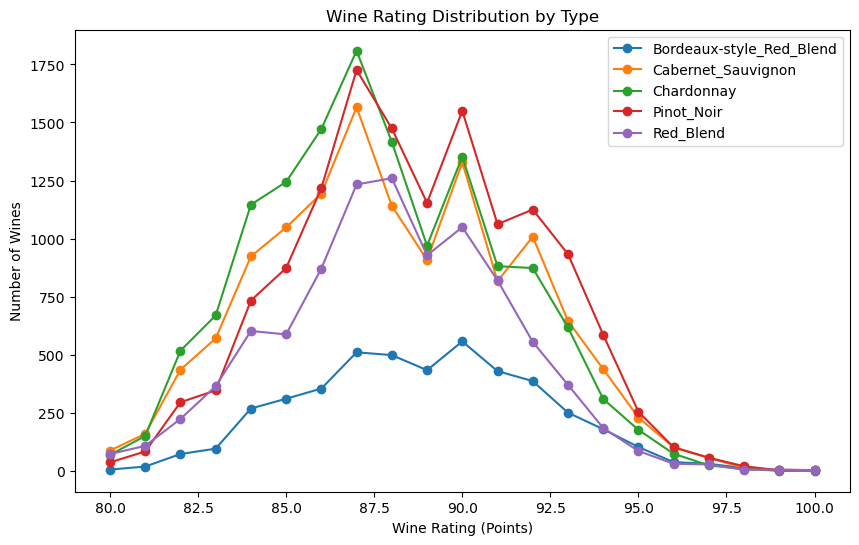

In [15]:
plt.figure(figsize=(10,6))

for col in df.columns[1:]:
    plt.plot(df["points"], df[col], marker='o', label=col)

plt.xlabel("Wine Rating (Points)")
plt.ylabel("Number of Wines")
plt.title("Wine Rating Distribution by Type")
plt.legend()
plt.show()

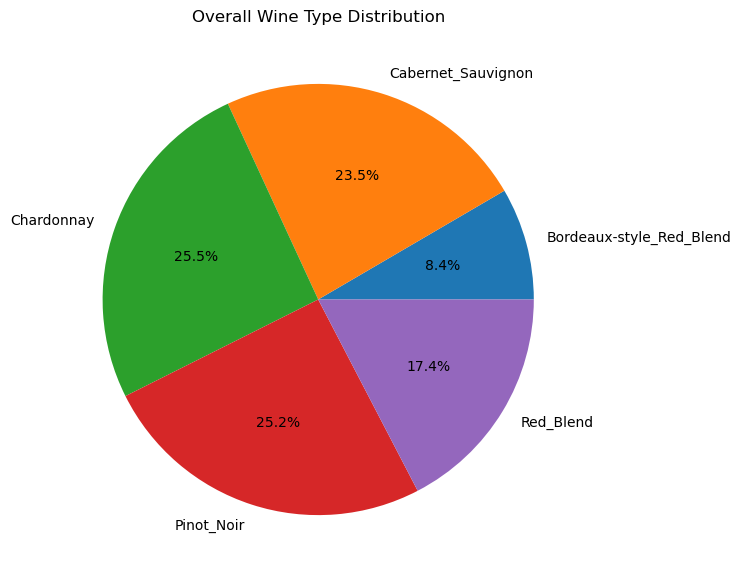

In [16]:
totals = df.drop("points", axis=1).sum()

plt.figure(figsize=(7,7))
plt.pie(totals.values, labels=totals.index, autopct='%1.1f%%')
plt.title("Overall Wine Type Distribution")
plt.show()

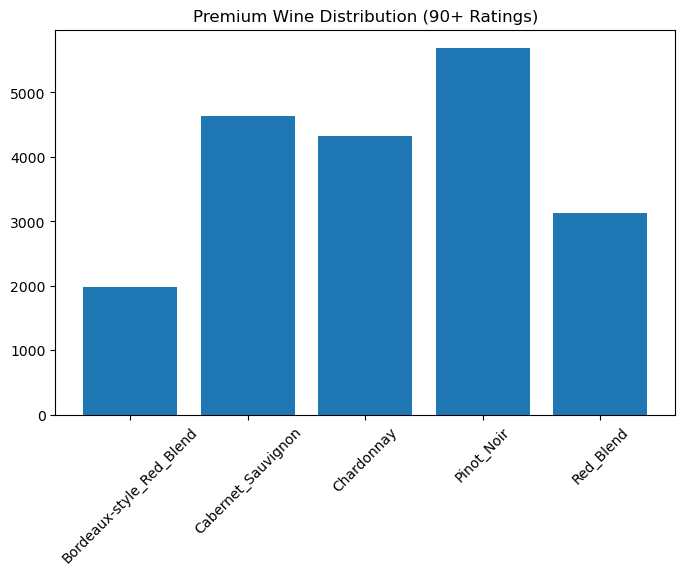

In [17]:
premium = df[df["points"] >= 90]
premium_totals = premium.drop("points", axis=1).sum()

plt.figure(figsize=(8,5))
plt.bar(premium_totals.index, premium_totals.values)
plt.xticks(rotation=45)
plt.title("Premium Wine Distribution (90+ Ratings)")
plt.show()

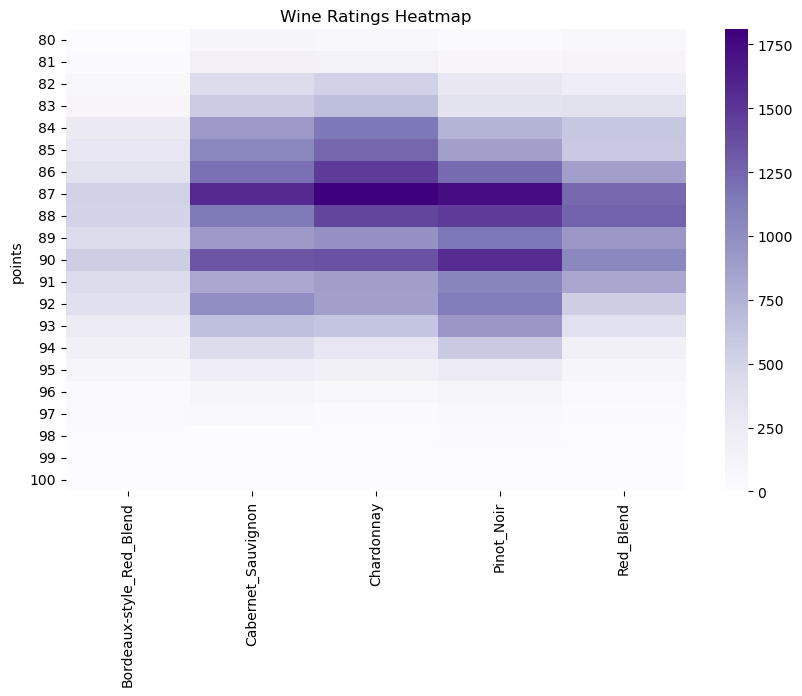

In [18]:

plt.figure(figsize=(10,6))
sb.heatmap(df.set_index("points"), cmap="Purples")
plt.title("Wine Ratings Heatmap")
plt.show()

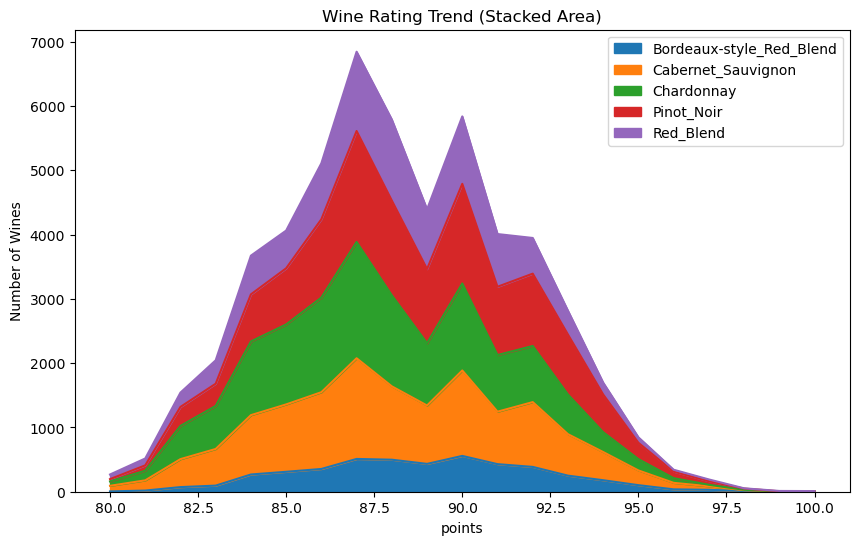

In [19]:
df.set_index("points").plot.area(figsize=(10,6))
plt.title("Wine Rating Trend (Stacked Area)")
plt.ylabel("Number of Wines")
plt.show()